# (advanced) using custom cortical atlas

**[note]** *this pipeline requires Connectome Workbench (`wb_command`) to be installed on your system to run the anatomical projections.*

sometimes you have a standard volumetric atlas (like the **AAL3 atlas**) that you want to visualize on the cortical surface using `yabplot.plot_cortical`.

since `plot_cortical` works with continuous surface vertices rather than blocky 3D voxels, we cannot simply pass the nifti file directly. instead, we need to **project** the 3D volume onto the 2d cortical sheet. 

this tutorial uses `yabplot`'s built-in wrapper for Connectome Workbench to perform highly accurate "ribbon-constrained" mapping, resulting in smooth, anatomically precise borders.

### inputs and outputs

**we start with:**
1.  **atlas volume (`.nii.gz`):** the 3D nifti file where each voxel has an integer region id.
2.  **atlas metadata (`.txt`, `.xml`, etc.):** a file listing what each region id represents (e.g., id 1 = "Precentral_L"). *(note: because every atlas publisher formats this differently, the parsing step always requires a custom script for your specific atlas)*

**we need to generate:**
1.  **vertex map (`.csv`):** a single column array of integers merging the left and right hemispheres. row 0 is the region id for vertex 0, row 1 for vertex 1, etc.
2.  **lookup table (`.txt`):** a file that tells `yabplot` the exact string name and rgb color to use for every integer id found in the csv map.

### the workflow
to achieve this conversion, our script will:
1.  parse the custom metadata into the strict Connectome Workbench label format.
2.  fetch standard high-resolution surface meshes (`fsLR32k`).
3.  project the nifti volume strictly into the cortical ribbon (between the white matter and pial surfaces).
4.  refine the map by erasing deep subcortical structures (if there is any) and masking out the medial wall.
5.  apply iterative surface smoothing and hole-filling to finalize the borders.

## step 1: configuration & file paths

In [1]:
import os
import numpy as np
import yabplot as yab

# define where your source NIfTI and text files are located
# you can download the same atlas for this tutorial in here:
# https://www.gin.cnrs.fr/wp-content/uploads/AAL3v2_for_SPM12.tar.gz
aal_txt = '/Users/to8050an/Developer/yabplot_miscfiles/AAL3/AAL3v1_1mm.nii.txt'
aal_nii = '/Users/to8050an/Developer/yabplot_miscfiles/AAL3/AAL3v1_1mm.nii.gz'

# define where the new atlas will be saved
workdir_wb = 'dev/my_custom_atlases/cortical/AAL3v1'
wb_label_list = os.path.join(workdir_wb, 'wb_labels.txt')
os.makedirs(workdir_wb, exist_ok=True)

## step 2: format the lookup table (LUT)

connectome workbench requires a highly specific text format. because every atlas 
publisher formats their `.txt` or `.csv` files differently, you must write a short loop 
to translate your specific atlas into the standard format required by `wb_command`.

the format requires two lines per region:
`region_name`
`id r g b a`  (where 'a' is alpha opacity, usually 255)

In [2]:
with open(aal_txt, 'r') as f_in, open(wb_label_list, 'w') as f_out:
    for line in f_in:
        parts = line.strip().split()
        if len(parts) >= 2:
            try:
                rid = int(parts[0])
                
                # clean up names to prevent plotting errors downstream
                name = parts[1].replace(' ', '_').replace('/', '-')
                
                # seed random RGB colors so they remain identical every time you run the script
                np.random.seed(rid) 
                r, g, b = np.random.randint(50, 255, 3)
                
                # write the two required lines
                f_out.write(f"{name}\n{rid} {r} {g} {b} 255\n")
                
            except ValueError: 
                continue

## step 3: exclude subcortical structures

deep brain structures (like the thalamus or amygdala) are 3D volumes that do not 
belong on the 2D cortical sheet. if left unchecked, the projection algorithm could 
smear them across the medial wall of the brain. we define them here so the builder 
can actively delete them from the final map.

In [3]:
exclude_keywords = [
    'Hippocampus', 'Amygdala', 'Caudate', 'Putamen', 'Pallidum', 'Thalamus', 'Thal',
    'Cerebellum', 'Vermis', 'N_Acc', 'VTA', 'SN', 'Red_N', 'LC', 'Raphe'
]

## step 4: run the atlas builder

this function manages the heavy lifting: downloading standard fsLR32k templates, 
wrapping the terminal commands, masking the medial wall, filling gaps, and 
aggressively smoothing boundaries to remove jagged voxel artifacts.

In [4]:
print("building cortical atlas...")
yab.build_cortical_atlas(
    nii_path=aal_nii,
    wb_txt_path=wb_label_list,
    out_dir=os.path.join(workdir_wb, "atlas"),
    exclude_list=exclude_keywords
)

building cortical atlas...
fetching standard surfaces...
running volume-to-surface projection...
found 88 initial cortical regions. mapping and cleaning...
building surface adjacency and filling holes...
smoothing boundaries...
[WARNING] Cingulate_Ant_L (id 35) lost during smoothing/masking. dropping from lut.
[WARNING] Cingulate_Ant_R (id 36) lost during smoothing/masking. dropping from lut.
final polished atlas saved to: dev/my_custom_atlases/cortical/AAL3v1/atlas
saved 86 regions (2 empty regions dropped).


## step 5: visualize and verify

the pipeline automatically creates the required `.csv` and `.txt` files in your 
output directory. you can now pass this folder directly into `yabplot`!

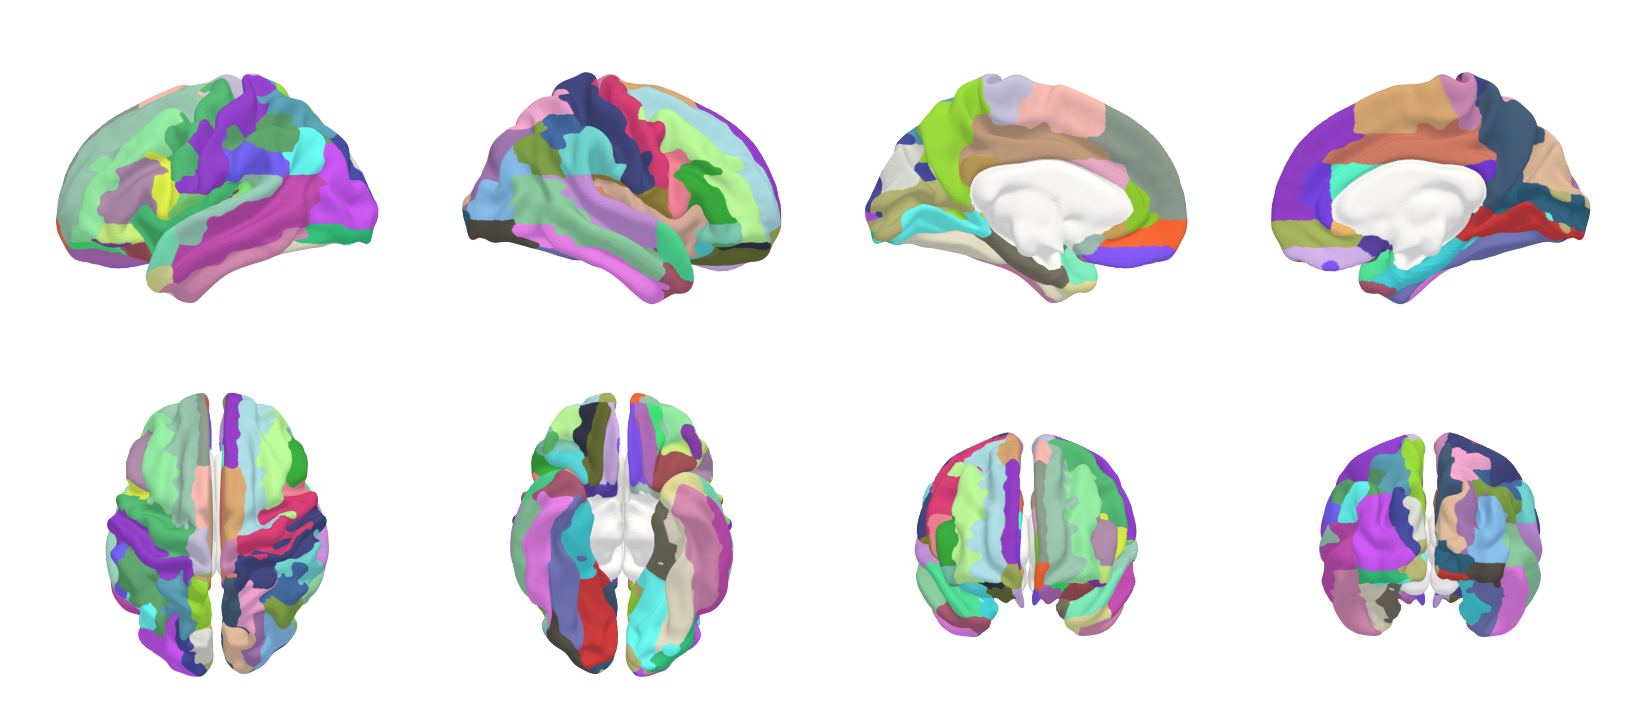

In [5]:
ax = yab.plot_cortical(custom_atlas_path=os.path.join(workdir_wb, "atlas"))

## step 6: quality control (QC)

converting 3D volumes to 2D surfaces can sometimes result in dropouts (where regions 
are too small to hit the surface mesh) or anatomical bleed. 

the `qc_custom_cortical_atlas` function automatically counts the exact number of vertices assigned 
to each region and saves a `.txt` summary. it also silently loops through the atlas 
and saves a picture of every individual region so you can quickly scan a folder 
to ensure everything is anatomically correct!

In [6]:
from yabplot.atlas_builder import qc_custom_cortical_atlas

# print("generating qc report...")
# qc_custom_cortical_atlas(atlas_dir=os.path.join(workdir_wb, "atlas"))